# Parte 4 · Análisis de robustez

**Visión por Computadora II · CEIA · FIUBA**

Evaluamos los cuatro checkpoints del notebook 03 sobre versiones perturbadas del conjunto de **test**.

La pregunta principal es si el *data augmentation*, aunque no mejore el test limpio, ayuda a que el modelo sea más robusto ante cambios de iluminación, orientación, escala y nitidez.

Las perturbaciones se fijan de antemano y no se ajustan según los resultados de test.

## 0. Configuración

In [2]:
import os
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from PIL import Image
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from torch.utils.data import DataLoader
from torchvision.transforms import v2
from torchvision.transforms import functional as TF


# La notebook está en VpC2/notebooks/
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Dataset descargado por la notebook 01
KAGGLE_DIR = PROJECT_ROOT / "data" / "PlantVillage"
DATA_DIR_LOCAL = (
    KAGGLE_DIR / "PlantVillage"
    if (KAGGLE_DIR / "PlantVillage").exists()
    else KAGGLE_DIR
)

if not DATA_DIR_LOCAL.exists():
    raise FileNotFoundError(
        f"No se encontró PlantVillage en {DATA_DIR_LOCAL}. "
        "Ejecutar primero la notebook 01."
    )

# common.py lee esta variable al importarse
os.environ["PV_DATA_DIR"] = str(DATA_DIR_LOCAL)

import common
importlib.reload(common)
from common import *


IMG_SIZE_FT = 160
BATCH_SIZE = 32
torch.set_num_threads(5)

df, classes = load_split()
short = [c.replace("__", "_").replace("_", " ") for c in classes]
test_df = df[df["split"] == "test"].reset_index(drop=True)

# Buscar los checkpoints donde pudo haberlos guardado la notebook 03
ckpt_candidates = [
    ROOT / "cache" / "ckpt_full",
    Path.home() / ".cache" / "vpc2" / "ckpt_full",
]
CKPT_DIR = next((p for p in ckpt_candidates if p.exists()), ckpt_candidates[0])

OUT_DIR = ROOT / "results" / "robustness"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"{len(test_df):,} imágenes de test | {len(classes)} clases")
print("Dataset:", DATA_DIR)
print("Checkpoints:", CKPT_DIR)


2,949 imágenes de test | 15 clases
Dataset: c:\Users\tolot\Documents\UBA\2026\uba-ai-master\VpC2\data\PlantVillage\PlantVillage
Checkpoints: C:\Users\tolot\Documents\UBA\2026\uba-ai-master\VpC2\cache\ckpt_full


## 1. Perturbaciones

Se usan cambios moderados y fáciles de interpretar:

- **dark / bright:** cambio de iluminación.
- **rotation_25:** rotación de 25°.
- **zoom_20:** acercamiento del 20%.
- **blur:** pérdida moderada de nitidez.

No se modifica el fondo automáticamente porque, sin segmentar la hoja, sería difícil cambiar solo el fondo sin alterar también el objeto de interés.

In [3]:
resize = v2.Resize((IMG_SIZE_FT, IMG_SIZE_FT))

RAW_PERTURBATIONS = {
    "clean": resize,
    "dark": v2.Compose([
        resize,
        lambda img: TF.adjust_brightness(img, 0.65),
    ]),
    "bright": v2.Compose([
        resize,
        lambda img: TF.adjust_brightness(img, 1.35),
    ]),
    "rotation_25": v2.Compose([
        v2.Resize((190, 190)),
        lambda img: TF.rotate(img, 25),
        v2.CenterCrop(IMG_SIZE_FT),
    ]),
    "zoom_20": v2.Compose([
        v2.Resize((192, 192)),
        v2.CenterCrop(IMG_SIZE_FT),
    ]),
    "blur": v2.Compose([
        resize,
        v2.GaussianBlur(kernel_size=5, sigma=(1.5, 1.5)),
    ]),
}

tail = [
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(IMAGENET_MEAN, IMAGENET_STD),
]

def model_transform(raw_tf):
    return v2.Compose([raw_tf, *tail])


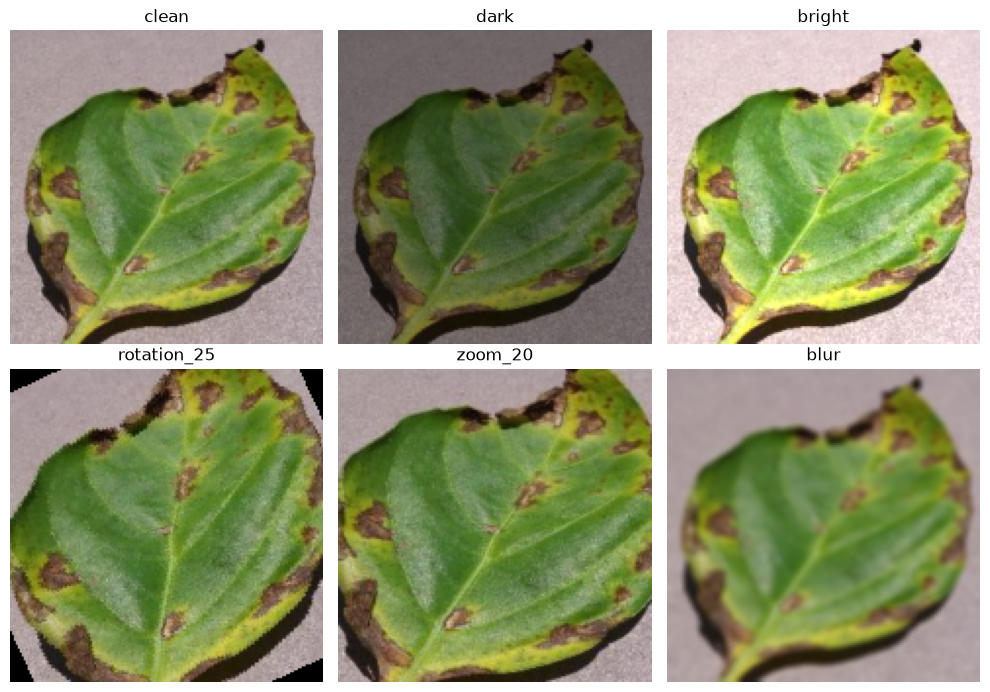

In [4]:
# Ejemplo visual de las perturbaciones
sample = Image.open(DATA_DIR / test_df.iloc[0]["relpath"]).convert("RGB")

fig, axes = plt.subplots(2, 3, figsize=(10, 7))
for ax, (name, tf) in zip(axes.ravel(), RAW_PERTURBATIONS.items()):
    ax.imshow(tf(sample))
    ax.set_title(name)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 2. Evaluación de los checkpoints

In [5]:
EXPERIMENTS = {
    "mnv3s_noaug": ("mobilenet_v3_small", 6, False),
    "mnv3s_aug":   ("mobilenet_v3_small", 6, True),
    "effb0_noaug": ("efficientnet_b0", 3, False),
    "effb0_aug":   ("efficientnet_b0", 3, True),
}

missing = [name for name in EXPERIMENTS if not (CKPT_DIR / f"{name}.pt").exists()]
if missing:
    raise FileNotFoundError(
        f"Faltan checkpoints en {CKPT_DIR}: {missing}. "
        "Ejecutar primero la notebook 03 en modo full."
    )

rows = []
predictions = {}

for run_name, (model_name, n_unfreeze, used_aug) in EXPERIMENTS.items():
    print(f"\nEvaluando {run_name}")

    net = finetune_model(model_name, len(classes), n_unfreeze)
    state = torch.load(CKPT_DIR / f"{run_name}.pt", map_location="cpu")
    net.load_state_dict(state)
    net.eval()

    for perturb_name, raw_tf in RAW_PERTURBATIONS.items():
        print(f"  - {perturb_name}")

        loader = DataLoader(
            PlantDataset(test_df, transform=model_transform(raw_tf)),
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=0,   # más robusto en Windows/Jupyter
        )

        logits, y_true = predict(net, loader)
        y_pred = logits.argmax(1)
        m = metrics(y_true, y_pred)

        predictions[(run_name, perturb_name)] = (y_true, y_pred)

        rows.append({
            "corrida": run_name,
            "modelo": model_name,
            "augmentation": used_aug,
            "perturbacion": perturb_name,
            **m,
        })

rob = pd.DataFrame(rows)
rob.to_csv(OUT_DIR / "robustness.csv", index=False)
rob.head()



Evaluando mnv3s_noaug
  - clean
  - dark
  - bright
  - rotation_25
  - zoom_20
  - blur

Evaluando mnv3s_aug
  - clean
  - dark
  - bright
  - rotation_25
  - zoom_20
  - blur

Evaluando effb0_noaug
  - clean
  - dark
  - bright
  - rotation_25
  - zoom_20
  - blur

Evaluando effb0_aug
  - clean
  - dark
  - bright
  - rotation_25
  - zoom_20
  - blur


,corrida,modelo,augmentation,perturbacion,accuracy,balanced_acc,macro_f1
0,mnv3s_noaug,mobilenet_v3_small,False,clean,0.991183,0.982238,0.984836
1,mnv3s_noaug,mobilenet_v3_small,False,dark,0.968803,0.954023,0.961561
2,mnv3s_noaug,mobilenet_v3_small,False,bright,0.982706,0.980368,0.979789
3,mnv3s_noaug,mobilenet_v3_small,False,rotation_25,0.889454,0.864359,0.870474
4,mnv3s_noaug,mobilenet_v3_small,False,zoom_20,0.964395,0.947007,0.954155


## 3. Resultados

Además del macro-F1 absoluto, se mide cuánto cae cada modelo respecto de su propio resultado sobre test limpio.

In [6]:
PERTURB_ORDER = list(RAW_PERTURBATIONS)

f1_table = (
    rob.pivot(index="perturbacion", columns="corrida", values="macro_f1")
       .reindex(PERTURB_ORDER)
)

f1_table.round(4)


corrida,effb0_aug,effb0_noaug,mnv3s_aug,mnv3s_noaug
perturbacion,,,,
clean,0.9929,0.9937,0.9851,0.9848
dark,0.9933,0.9890,0.9842,0.9616
bright,0.9910,0.9884,0.9853,0.9798
rotation_25,0.9909,0.8947,0.9738,0.8705
zoom_20,0.9941,0.9854,0.9871,0.9542
blur,0.9841,0.8066,0.9763,0.8063


Caída de macro-F1 respecto del test limpio:


corrida,effb0_aug,effb0_noaug,mnv3s_aug,mnv3s_noaug
perturbacion,,,,
clean,0.0000,0.0000,0.0000,0.0000
dark,-0.0004,0.0046,0.0010,0.0233
bright,0.0020,0.0052,-0.0002,0.0050
rotation_25,0.0020,0.0989,0.0114,0.1144
zoom_20,-0.0012,0.0083,-0.0020,0.0307
blur,0.0088,0.1870,0.0088,0.1786


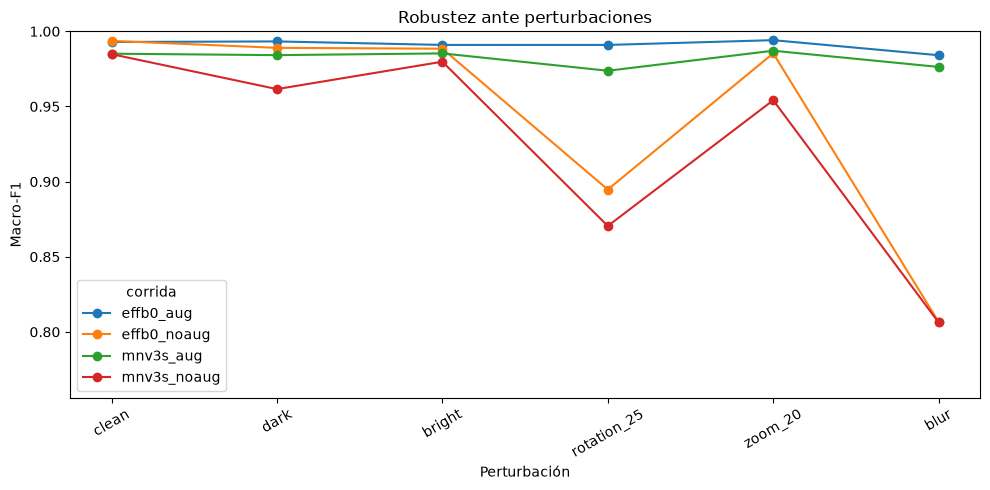

In [7]:
clean = f1_table.loc["clean"]
drop_table = clean - f1_table

print("Caída de macro-F1 respecto del test limpio:")
display(drop_table.round(4))

ax = f1_table.plot(marker="o", figsize=(10, 5))
ax.set_ylabel("Macro-F1")
ax.set_xlabel("Perturbación")
ax.set_ylim(max(0, f1_table.min().min() - 0.05), 1.0)
ax.set_title("Robustez ante perturbaciones")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 4. ¿Ayuda el data augmentation?

Para cada arquitectura se calcula:

**macro-F1 con augmentation − macro-F1 sin augmentation**

Un valor positivo indica que el modelo entrenado con augmentation fue más robusto en esa condición.

In [8]:
aug_gain = pd.DataFrame({
    "MobileNetV3-Small": (
        f1_table["mnv3s_aug"] - f1_table["mnv3s_noaug"]
    ),
    "EfficientNet-B0": (
        f1_table["effb0_aug"] - f1_table["effb0_noaug"]
    ),
})

print("Ganancia de macro-F1 por usar augmentation (positivo = mejora):")
display(aug_gain.round(4))

summary_robustness = pd.DataFrame({
    "macro-F1 clean": f1_table.loc["clean"],
    "macro-F1 promedio perturbado": f1_table.drop(index="clean").mean(),
    "peor macro-F1": f1_table.drop(index="clean").min(),
})

summary_robustness["caída promedio"] = (
    summary_robustness["macro-F1 clean"]
    - summary_robustness["macro-F1 promedio perturbado"]
)

summary_robustness.round(4)


Ganancia de macro-F1 por usar augmentation (positivo = mejora):


,MobileNetV3-Small,EfficientNet-B0
perturbacion,,
clean,0.0003,-0.0008
dark,0.0226,0.0043
bright,0.0055,0.0025
rotation_25,0.1033,0.0962
zoom_20,0.0329,0.0087
blur,0.1701,0.1775


,macro-F1 clean,macro-F1 promedio perturbado,peor macro-F1,caída promedio
corrida,,,,
effb0_aug,0.9929,0.9907,0.9841,0.0022
effb0_noaug,0.9937,0.9328,0.8066,0.0608
mnv3s_aug,0.9851,0.9813,0.9738,0.0038
mnv3s_noaug,0.9848,0.9144,0.8063,0.0704


## 5. Análisis del caso más difícil

Se toma como modelo principal la corrida elegida por **macro-F1 de validación** en el notebook 03 y se analiza la perturbación donde más cae.

In [9]:
summary_path = ROOT / "results" / "finetune_full" / "summary.csv"
summary = pd.read_csv(summary_path, index_col=0)

BEST = summary["val macro-F1"].idxmax()
worst = (
    f1_table[BEST]
    .drop(index="clean")
    .idxmin()
)

print("Modelo elegido por validación:", BEST)
print("Perturbación más difícil:", worst)

y_true, y_pred = predictions[(BEST, worst)]

report = pd.DataFrame(
    classification_report(
        y_true,
        y_pred,
        labels=range(len(classes)),
        target_names=short,
        output_dict=True,
        zero_division=0,
    )
).T

report.loc[short, ["precision", "recall", "f1-score", "support"]].sort_values("f1-score").round(3)

Modelo elegido por validación: effb0_aug
Perturbación más difícil: blur


,precision,recall,f1-score,support
Tomato Early blight,0.957,0.937,0.947,143.0
Tomato Tomato mosaic virus,0.963,0.981,0.972,53.0
Tomato Leaf Mold,0.978,0.971,0.974,136.0
Potato healthy,1.000,0.952,0.976,21.0
Tomato Spider mites Two spotted spider mite,0.967,0.987,0.977,239.0
Tomato Target Spot,0.971,0.985,0.978,201.0
Tomato Bacterial spot,0.993,0.974,0.983,304.0
Tomato Septoria leaf spot,0.988,0.988,0.988,253.0
Tomato Late blight,0.989,0.989,0.989,273.0
Tomato Tomato YellowLeaf Curl Virus,0.989,0.996,0.992,458.0


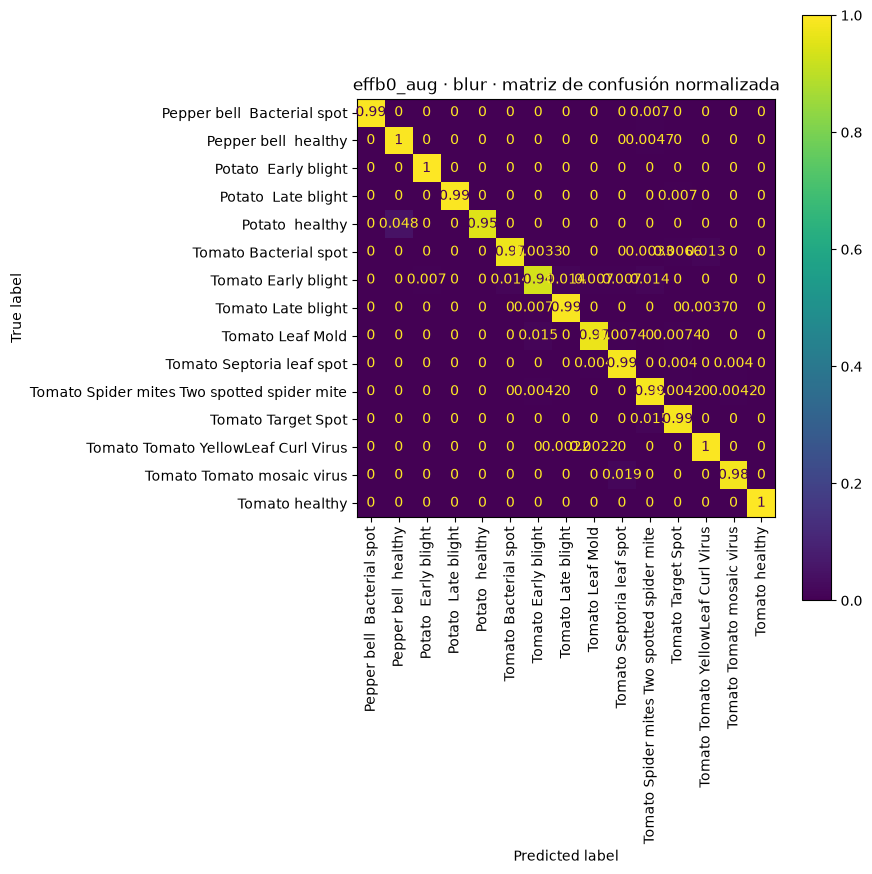

In [10]:
fig, ax = plt.subplots(figsize=(9, 9))
ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=short,
    normalize="true",
    xticks_rotation=90,
    ax=ax,
)
ax.set_title(f"{BEST} · {worst} · matriz de confusión normalizada")
plt.tight_layout()
plt.show()

## 6. Conclusión

Con este experimento se puede responder:

1. Qué perturbaciones afectan más a los modelos.
2. Qué arquitectura conserva mejor su desempeño fuera de las condiciones originales.
3. Si el entrenamiento con data augmentation mejora la robustez aunque no mejore el test limpio.

Los resultados se guardan en `results/robustness/robustness.csv`.